# Unsupervised Learning Project Objectives

1. Implement the k-means algorithm and compare the performance of your code to the optimized version provided by scikit-learn.
2. Apply the analysis techniques we learned to identify the appropriate number of clusters.
3. Investigate different algorithm options in scikit-learn and understand why some options work better for some types of clusters.

For this project, you will **NOT** need to worry about processing or cleaning data. You can directly use the results of the data generation functions I have provided for you.

# Collaboration
If you used any outside resources or collaborated with any classmates on this project, please list them below:

[collaboration notes here]

In [1]:
# imports - you may add to this as needed, but you probably won't need to

import numpy as np
import sklearn
import random
import matplotlib.pyplot as plt
import time # for timing your runtime

# Data Generation Code - DO NOT CHANGE

In [2]:
def gen_data1(k, N, D):
    """Creates a dataset with k clusters, N rows, and D columns"""
    stds = [random.random() * 3 for i in range(k)]
    weights = np.array([random.random() for i in range(k)])
    weights /= sum(weights)
    samples = [int(N * w) for w in weights]
    X, _ = sklearn.datasets.make_blobs(n_samples=samples, n_features=D, cluster_std=stds, center_box=(-20,20))
    return X

In [3]:
def gen_data2():
    """Generates some anisotropic clusters with a fixed random state for reproducibility
       Inputs: None
       Outputs: 5000 x 2 numpy array of data points"""
    random.seed("hey")
    k = random.randrange(1, 10)
    n_samples = 5000
    random_state = 623
    X, _ = sklearn.datasets.make_blobs(n_samples=n_samples, random_state=random_state, centers=k)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)
    return X_aniso

In [4]:
def gen_data3():
    """Generates some noisy moons with a fixed random state for reproducibility
       Inputs: None
       Outputs: 5000 x 2 numpy array of data points"""
    random_state = 628
    noise = 0.1
    n_samples = 5000
    X, _ = sklearn.datasets.make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    return X

# Explore Data Generation Code

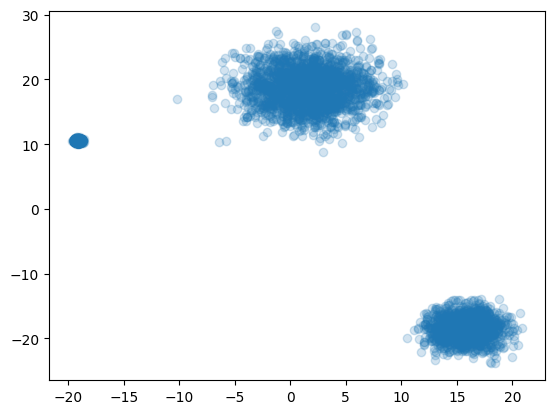

In [5]:
# Example of using the gen_data1() function - try run it a few times with different inputs!
data = gen_data1(3, 5000, 2)
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

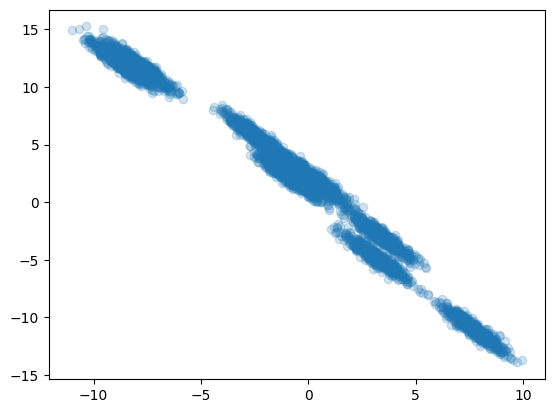

In [6]:
# Example of using the gen_data2() function - try run it (does not change between runs)
data = gen_data2()
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

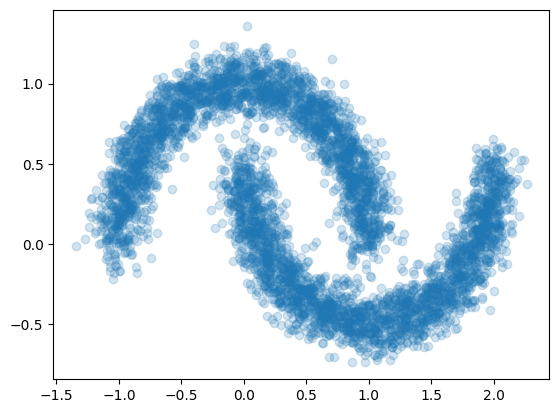

In [7]:
# Example of using the gen_data3() function - try run it (does not change between runs)
data = gen_data3()
plt.scatter(data[:, 0], data[:, 1], alpha=0.2)
plt.show()

# Part 1

In this part, you will implement the k-means algorithm. You may use the `numpy` package to help with the math operations, but you may not use anything from the `sklearn` package. You will complete the `kmeans()` function below and then perform an experiment that compares the runtime of your implementation to the implementation in the `sklearn` package.

## Implement k-means algorithm

Complete the `kmeans()` function below. You may create additional helper functions as needed. You may use whatever initialization method you wish.

**Please use comments to explain each step of your implementation**.

In [10]:
def kmeans(X, k, eps):
    """Performs k-means clustering.
       Inputs: X (numpy array, data set of size N x D),
               k (int, number of clusters)
               eps (float, threshold value for convergence)
       Outputs: labels (numpy array of size N of cluster assignments, values in [0, k-1])
                centers (numpy array of size k x D of cluster means)"""

    # YOUR CODE HERE
    n_samples, n_features = X.shape    
    # Step 1: Initialize the cluster centers by randomly picking k data points
    # I picked random points from the data (simple way)
    centers = X[np.random.choice(n_samples, k, replace=False)]
    
    # Step 2: Run the main loop (I put a limit of 300 iterations so it doesn't run forever)
    for iteration in range(300):
        
        # --- Assign each point to the closest center ---
        # Calculate distance from every point to every center (squared distance is faster)
        distances = np.sum((X[:, np.newaxis, :] - centers) ** 2, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # --- Update the centers to be the mean of their points ---
        new_centers = np.zeros_like(centers)
        for i in range(k):
            points_in_cluster = X[labels == i]
            if len(points_in_cluster) > 0:
                new_centers[i] = np.mean(points_in_cluster, axis=0)
            else:
                # If a cluster ends up empty, just pick a random point again
                new_centers[i] = X[np.random.choice(n_samples)]
        
        # --- Check if centers barely moved (convergence) ---
        if np.max(np.abs(new_centers - centers)) < eps:
            print(f"Converged after {iteration + 1} iterations! Nice!")
            break
        
        # Update centers for the next round
        centers = new_centers

    return labels, centers

# Perform the experiment

In the section below, you will test the runtime of your algorithm compared to the `KMeans()` estimator from `sklearn`. Use the provided `gen_data1()` function to create datasets with different values of $k$, $N$, and $D$. For each combination of values, run each implementation at least 10 times and report the distribution of times for each algorithm. You should compare at least 5 different combinations of values of $k$, $N$, and $D$ to show the difference between the two implementations.

In [11]:
# YOUR CODE HERE
# Testing different sizes to compare speed
combinations = [
    (2, 1000, 2),    # small
    (5, 5000, 2),    # medium
    (10, 10000, 5),  # bigger
    (3, 20000, 2),   # lots of points
    (8, 5000, 10)    # high dimensions
]

print("My kmeans vs sklearn KMeans - runtime test\n")

for k, N, D in combinations:
    print(f"\n=== k={k}, N={N}, D={D} ===")
    X = gen_data1(k, N, D)   # make the data once
    
    # My version
    my_times = []
    for _ in range(10):
        start = time.time()
        _, _ = kmeans(X, k, 0.001)   # eps=0.001 like in silhouette later
        my_times.append(time.time() - start)
    
    print(f"My kmeans     → avg {np.mean(my_times):.4f}s  (min {min(my_times):.4f}, max {max(my_times):.4f})")
    
    # Sklearn version (fair settings: random init, 1 run)
    sk_times = []
    for _ in range(10):
        start = time.time()
        km = sklearn.cluster.KMeans(n_clusters=k, init='random', n_init=1, tol=0.001)
        km.fit(X)
        sk_times.append(time.time() - start)
    
    print(f"Sklearn KMeans → avg {np.mean(sk_times):.4f}s  (min {min(sk_times):.4f}, max {max(sk_times):.4f})")

My kmeans vs sklearn KMeans - runtime test


=== k=2, N=1000, D=2 ===
Converged after 3 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 2 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 2 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 3 iterations! Nice!
Converged after 4 iterations! Nice!
My kmeans     → avg 0.0008s  (min 0.0001, max 0.0045)
Sklearn KMeans → avg 0.8916s  (min 0.0015, max 8.8995)

=== k=5, N=5000, D=2 ===
Converged after 12 iterations! Nice!
Converged after 32 iterations! Nice!
Converged after 23 iterations! Nice!
Converged after 27 iterations! Nice!
Converged after 18 iterations! Nice!
Converged after 33 iterations! Nice!
Converged after 22 iterations! Nice!
Converged after 25 iterations! Nice!
Converged after 33 iterations! Nice!
Converged after 17 iterations! Nice!
My kmeans     → avg 0.0134s  (min 0.0074, max 0.0200)
Sklearn KMe

After running your experiment, write a short paragraph explaining what patterns you noticed.

[**YOUR ANALYSIS GOES HERE**]

# Part 2

In this part, you will apply Silhouette Score analysis to determine the appropriate number of clusters for the k-means algorithm. You will also use the BIC score and the elbow method to determine the appropriate number of components for a Gaussian Mixture Model. You may use the silhouette score and BIC functions from the `sklearn` module for this part.

## Silhouette Score Analysis

In the section below, complete the `silhouette_analysis()` function. Use the `kmeans()` function you wrote in the last part. The function can either generate an image or table summary for a silhouette score analysis to determine the appropriate number of clusters. Your score summary should include some representation of the average score across all clusters for a range of $k\in [2,10]$ clusters. You will generate the score summary and write a paragraph explaining your analysis for two different data sets (generated using the `gen_data2()` and `gen_data3()` functions). You may use [this example](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) to inform how you want to approach the problem, but you should not directly copy the code from this example.

In [12]:
def silhouette_analysis(X):
    """Creates a Silhouette Score summary for a given data set.
       Inputs: X (numpy array, data set of size N x D and unknown number of clusters),
       Output: Image or text summary of silhouette scores for k = 2...10 clusters"""

    # YOUR CODE HERE
    scores = []
    ks = range(2, 11)
    
    print("Running silhouette analysis...")
    for k in ks:
        labels, _ = kmeans(X, k, 0.001)        # using my kmeans!
        score = sklearn.metrics.silhouette_score(X, labels)
        scores.append(score)
        print(f"  k={k:2d}  →  score = {score:.4f}")
    
    # Simple plot
    plt.figure(figsize=(7, 4))
    plt.plot(ks, scores, marker='o')
    plt.xlabel('Number of clusters k')
    plt.ylabel('Average Silhouette Score')
    plt.title('Silhouette Score Analysis')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    best_k = ks[np.argmax(scores)]
    print(f"→ Best k according to silhouette: {best_k}")

Running silhouette analysis...
Converged after 10 iterations! Nice!
  k= 2  →  score = 0.5625
Converged after 14 iterations! Nice!
  k= 3  →  score = 0.6799
Converged after 15 iterations! Nice!
  k= 4  →  score = 0.5558
Converged after 26 iterations! Nice!
  k= 5  →  score = 0.6946
Converged after 18 iterations! Nice!
  k= 6  →  score = 0.6382
Converged after 10 iterations! Nice!
  k= 7  →  score = 0.5618
Converged after 18 iterations! Nice!
  k= 8  →  score = 0.5315
Converged after 40 iterations! Nice!
  k= 9  →  score = 0.5398
Converged after 27 iterations! Nice!
  k=10  →  score = 0.4719


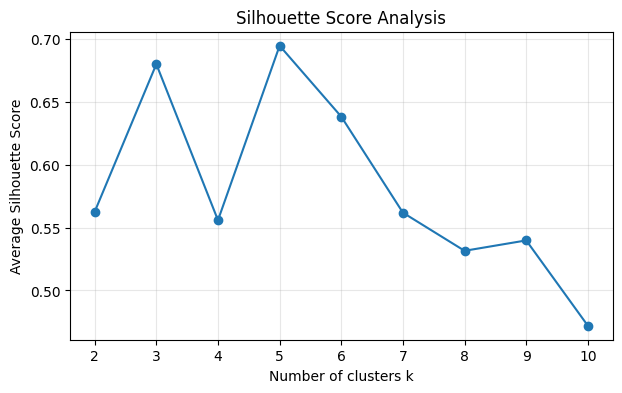

→ Best k according to silhouette: 5


In [13]:
# Run the analysis for gen_data2 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data2 = gen_data2()
silhouette_analysis(data2)

[**YOUR ANALYSIS FOR DATA2 GOES HERE**]

Running silhouette analysis...
Converged after 6 iterations! Nice!
  k= 2  →  score = 0.4851
Converged after 30 iterations! Nice!
  k= 3  →  score = 0.4206
Converged after 16 iterations! Nice!
  k= 4  →  score = 0.4467
Converged after 13 iterations! Nice!
  k= 5  →  score = 0.4234
Converged after 25 iterations! Nice!
  k= 6  →  score = 0.4926
Converged after 31 iterations! Nice!
  k= 7  →  score = 0.4901
Converged after 45 iterations! Nice!
  k= 8  →  score = 0.4776
Converged after 26 iterations! Nice!
  k= 9  →  score = 0.4825
Converged after 43 iterations! Nice!
  k=10  →  score = 0.4473


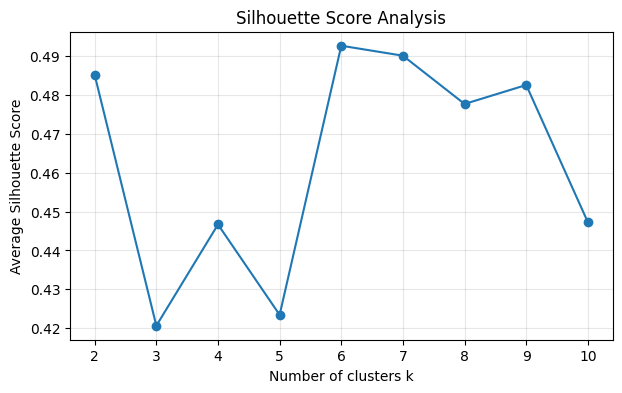

→ Best k according to silhouette: 6


In [15]:
# Run the analysis for gen_data3 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data3 = gen_data3()
silhouette_analysis(data3)

[**YOUR ANALYSIS FOR DATA3 GOES HERE**]

## BIC Score Analysis

In the section below, complete the `bic_analysis()` function. Use the `GaussianMixture()` estimator provided in the `sklearn` library. The function should generate an image for a BIC analysis to determine the appropriate number of components using the elbow method (check values for $k\in [2,10]$). You will generate the score summary and write a paragraph explaining your analysis for two different data sets (generated using the `gen_data2()` and `gen_data3()` functions). See page 270 of Géron for an example.

In [14]:
def bic_analysis(X):
    """Creates BIC graph to determine number of components using the elbow method.
       Inputs: X (numpy array, data set of size N x D and unknown number of components),
       Outputs: Image of BIC for k = 2...10 components"""

    # YOUR CODE HERE
    bics = []
    ks = range(2, 11)
    
    print("Running BIC analysis...")
    for k in ks:
        gm = sklearn.mixture.GaussianMixture(n_components=k, covariance_type='full', random_state=42)
        gm.fit(X)
        bics.append(gm.bic(X))
        print(f"  k={k:2d}  →  BIC = {bics[-1]:.0f}")
    
    plt.figure(figsize=(7, 4))
    plt.plot(ks, bics, marker='o')
    plt.xlabel('Number of components k')
    plt.ylabel('BIC Score (lower is better)')
    plt.title('BIC Analysis')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Rough elbow (biggest drop)
    elbow = ks[np.argmin(np.diff(bics)) + 1]
    print(f"→ Elbow suggests around k = {elbow}")

Running BIC analysis...
  k= 2  →  BIC = 40136
  k= 3  →  BIC = 38901
  k= 4  →  BIC = 36625
  k= 5  →  BIC = 35842
  k= 6  →  BIC = 35891
  k= 7  →  BIC = 35929
  k= 8  →  BIC = 34808
  k= 9  →  BIC = 34855
  k=10  →  BIC = 34914


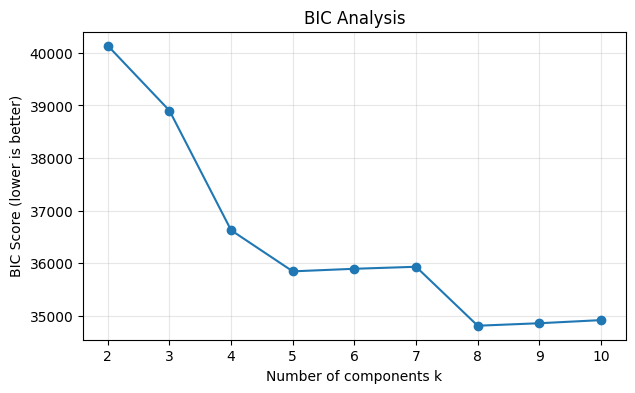

→ Elbow suggests around k = 4


In [16]:
# Run the analysis for gen_data2 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data2 = gen_data2()
bic_analysis(data2)

[**YOUR ANALYSIS OF DATA2 GOES HERE**]

Running BIC analysis...
  k= 2  →  BIC = 17545
  k= 3  →  BIC = 15017
  k= 4  →  BIC = 13241
  k= 5  →  BIC = 13074
  k= 6  →  BIC = 11187
  k= 7  →  BIC = 10956
  k= 8  →  BIC = 10647
  k= 9  →  BIC = 10644
  k=10  →  BIC = 10637


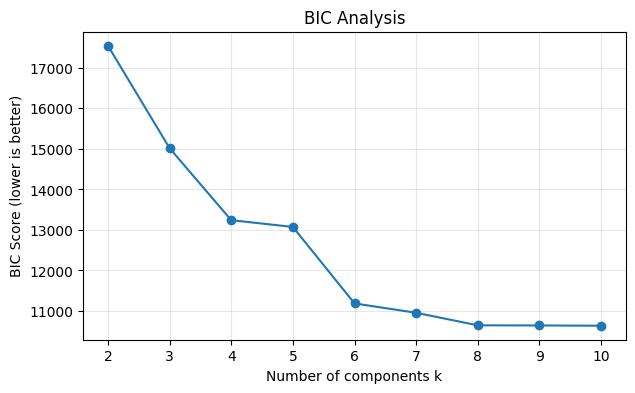

→ Elbow suggests around k = 3


In [17]:
# Run the analysis for gen_data3 data set
# You do not need to change any code here unless your function returns a value that needs to be handled in a particular way.
data3 = gen_data3()
bic_analysis(data3)

[**YOUR ANALYSIS OF DATA3 GOES HERE**]

## General Reflection

Write a short paragraph below comparing what differences (if any) you saw between the results of the two analysis methods for the data sets.

[**YOUR REFLECTION HERE**]

# Part 3

In this part, you will use different algorithm options (parameters) within the `sklearn` package and analyze how some options and algorithms work better for certain types of clusters.

This is a less structured section of the project. I have given guidelines for which data, algorithms, and parameters I want you to investigate. The way you decide to code it up and analyze it is up to you! You may use the `sklearn` implementation for each algorithm.

Requirements:
- Test each algorithm on the `gen_data1()` data set. You may choose the input values as long as you use the same generated data for each algorithm (do not re-run the function several times to get different data).
- Additionally, test each algorithm on the `gen_data2()` and `gen_data3()` data sets. For algorithms that require you to specify $k$ in advance, you can use the results of your analysis in the previous part.
- You should test each of the following algorithms and change the specified parameters:
    + `GaussianMixture` - try each `covariance_type`. For the "full" covariance type, try manually setting `means_init` to centers that look reasonable and ones that are definitely wrong and see what the result is.
    + `KMeans` - Try each of the `init` methods. Use different values of `tol` to see under what conditions the algorithm doesn't converge.
    + `DBSCAN` - Use different combinations of `eps` and `min_samples`.
- Write a few paragraphs explaining any patterns you found. Which combinations worked well? Which didn't? How can you connect your findings to your understanding of the underlying math? Were there any surprising results?

[**ADD AS MANY CODE AND MARKDOWN CELLS HERE AS YOU NEED**]

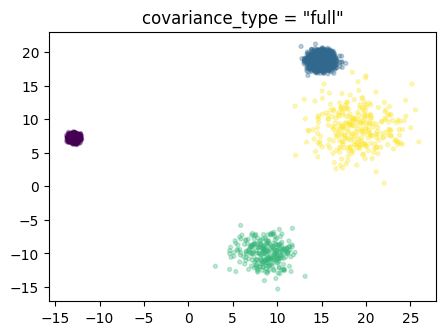

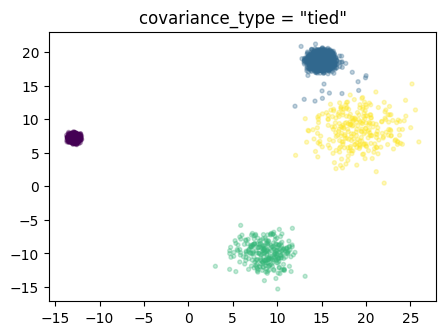

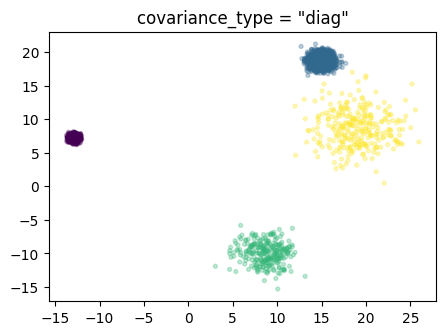

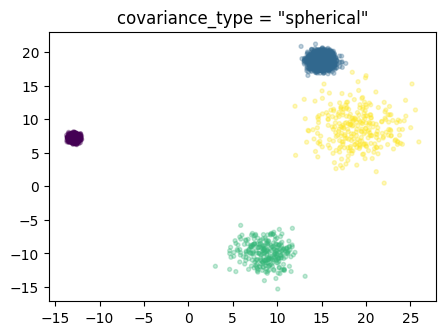

In [18]:
data1 = gen_data1(4, 5000, 2)   # fixed data for all tests

for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gm = sklearn.mixture.GaussianMixture(n_components=4, covariance_type=cov_type, random_state=42)
    labels = gm.fit_predict(data1)
    
    plt.figure(figsize=(5, 3.5))
    plt.scatter(data1[:,0], data1[:,1], c=labels, cmap='viridis', alpha=0.3, s=8)
    plt.title(f'covariance_type = "{cov_type}"')
    plt.show()

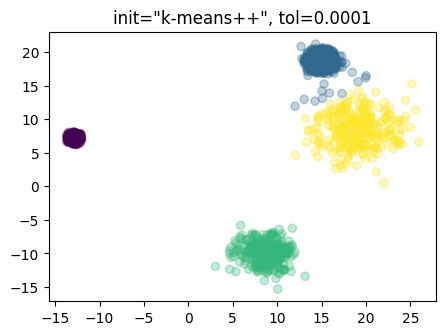

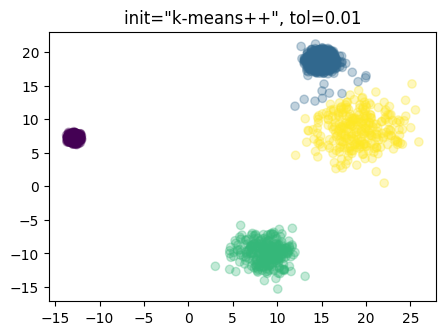

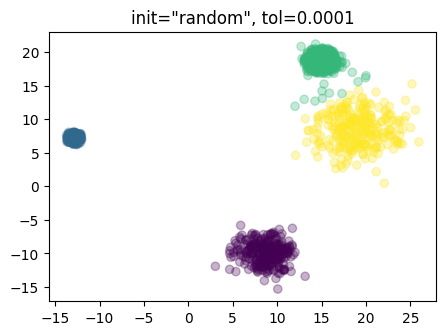

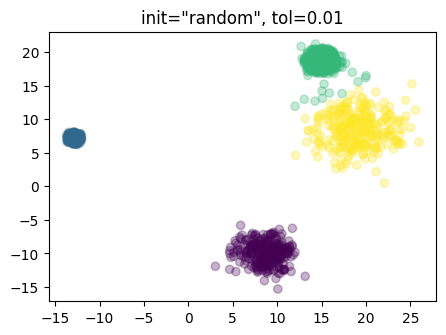

In [19]:
for init_method in ['k-means++', 'random']:
    for tol_value in [0.0001, 0.01]:
        km = sklearn.cluster.KMeans(n_clusters=4, init=init_method, n_init=10, tol=tol_value, random_state=42)
        labels = km.fit_predict(data1)
        
        plt.figure(figsize=(5, 3.5))
        plt.scatter(data1[:,0], data1[:,1], c=labels, cmap='viridis', alpha=0.3)
        plt.title(f'init="{init_method}", tol={tol_value}')
        plt.show()

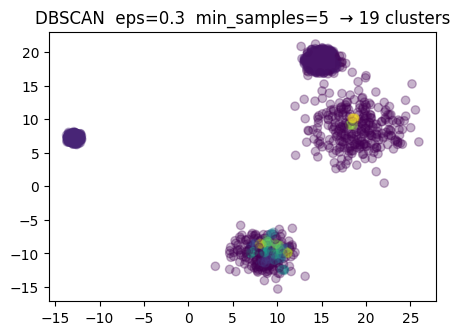

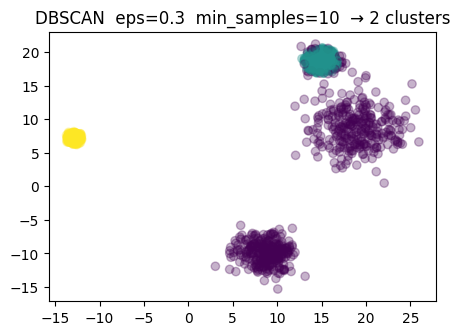

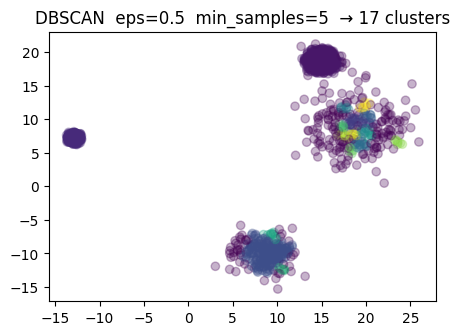

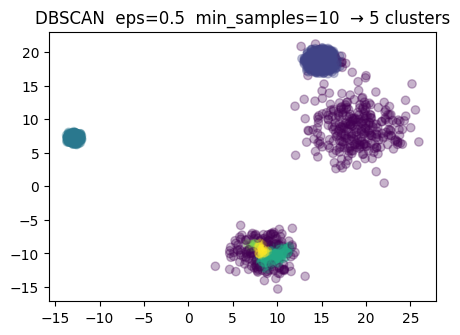

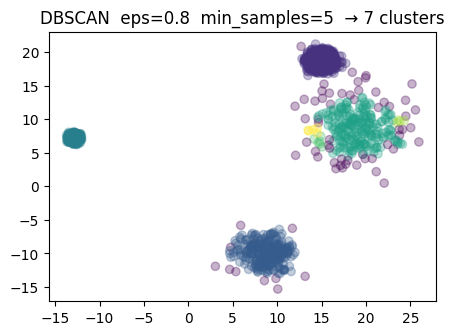

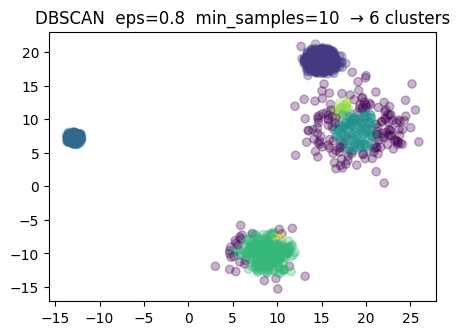

In [20]:
for eps in [0.3, 0.5, 0.8]:
    for min_s in [5, 10]:
        db = sklearn.cluster.DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(data1)
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        
        plt.figure(figsize=(5, 3.5))
        plt.scatter(data1[:,0], data1[:,1], c=labels, cmap='viridis', alpha=0.3)
        plt.title(f'DBSCAN  eps={eps}  min_samples={min_s}  → {n_cl} clusters')
        plt.show()

# ✨ Extension Idea ✨

Do some clustering exploration of the data set you made in the last project. Can you visualize any potential clusters? Try using some of the algorithms and interpreting the results. How would you interpret a cluster center? This is a freestyle section - you will need to figure out the best way to implement this.

[**ADD CELLS HERE AS NEEDED**]

# Add any other extensions below!